In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import cv2

# For nicer printing
pd.set_option("display.max_columns", 50)

DATA_ROOT = r"D:/Fyp_project_root/data/bodym-dataset"
print("Using data root:", DATA_ROOT)


Using data root: D:/Fyp_project_root/data/bodym-dataset


In [2]:
# --- Load measurements (silhouette-derived lengths/circumferences) ---
meas_train = pd.read_csv(os.path.join(DATA_ROOT, "train/measurements.csv"))
meas_A     = pd.read_csv(os.path.join(DATA_ROOT, "testA/measurements.csv"))
meas_B     = pd.read_csv(os.path.join(DATA_ROOT, "testB/measurements.csv"))

df_sil = pd.concat([meas_train, meas_A, meas_B], ignore_index=True)

# --- Load metadata (height, weight, gender) ---
meta_train = pd.read_csv(os.path.join(DATA_ROOT, "train/hwg_metadata.csv"))
meta_A     = pd.read_csv(os.path.join(DATA_ROOT, "testA/hwg_metadata.csv"))
meta_B     = pd.read_csv(os.path.join(DATA_ROOT, "testB/hwg_metadata.csv"))

df_meta = pd.concat([meta_train, meta_A, meta_B], ignore_index=True)

print("Silhouette measurements shape:", df_sil.shape)
print("HWG metadata shape:", df_meta.shape)

# --- Merge on subject_id ---
df_merged = df_sil.merge(df_meta, on="subject_id", how="inner")

# --- Compute BMI ---
df_merged["height_m"] = df_merged["height_cm"].astype(float) / 100.0
df_merged["weight_kg"] = df_merged["weight_kg"].astype(float)
df_merged["bmi"] = df_merged["weight_kg"] / (df_merged["height_m"] ** 2)

print("Merged shape:", df_merged.shape)
df_merged[["subject_id", "height_cm", "weight_kg", "bmi"]].head()


Silhouette measurements shape: (2505, 15)
HWG metadata shape: (2505, 4)
Merged shape: (2507, 20)


,subject_id,height_cm,weight_kg,bmi
0,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,178.0,79.6,25.123091
1,-5OHO2b5mRDY1rvAf07sYYtekEEX7ViEGmvRr7l4tfc,163.0,65.0,24.464602
2,-5iHTazqnmWBsnUY6ymoCw1kORMymRDaUla1eNOjgvI,185.0,82.9,24.222060
3,-60o95b9oEE83BDV3GpsAVPA4TFvxuPPqtXEY5PApy8,166.0,88.7,32.188997
4,-67TrwlJ3GSsqPeHaa2Nb0iQ-BKZfIx4ERysQPZ0-SY,144.6,44.2,21.139061


         height_cm    weight_kg          bmi
count  2507.000000  2507.000000  2507.000000
mean    170.570226    74.279803    25.416270
std       9.482867    16.898214     4.952345
min     141.000000    28.700000    10.618869
25%     163.825000    62.100000    22.152356
50%     170.750000    72.500000    24.615150
75%     177.500000    83.950000    27.506728
max     197.500000   184.500000    62.809813


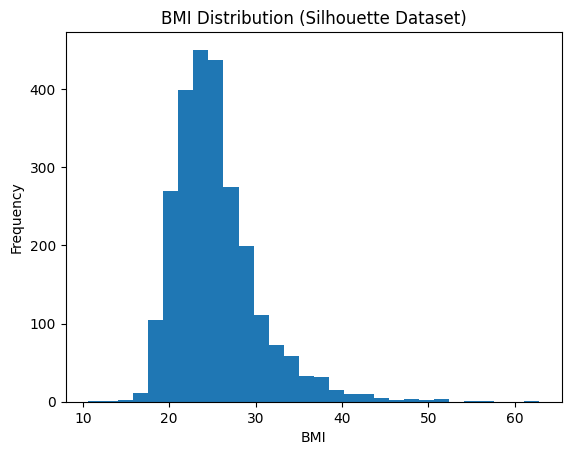

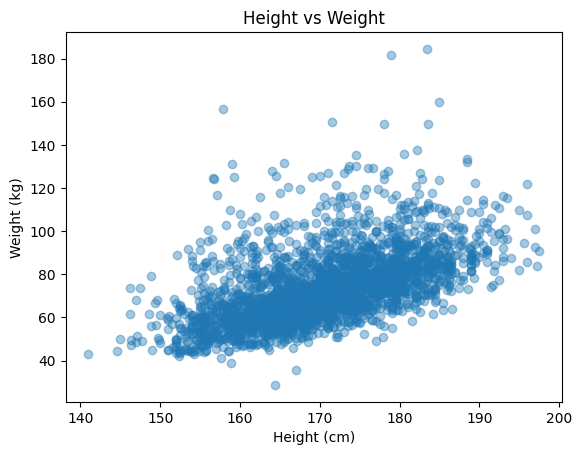

In [3]:
print(df_merged[["height_cm", "weight_kg", "bmi"]].describe())

plt.hist(df_merged["bmi"], bins=30)
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.title("BMI Distribution (Silhouette Dataset)")
plt.show()

plt.scatter(df_merged["height_cm"], df_merged["weight_kg"], alpha=0.4)
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Height vs Weight")
plt.show()


In [4]:
# subject_id -> photo_id mapping (only provided for train/masks)
map_path = os.path.join(DATA_ROOT, "train/subject_to_photo_map.csv")
df_map = pd.read_csv(map_path)

print(df_map.head())
print("Map shape:", df_map.shape)

# Merge measurements+metadata with mapping
df_full = df_merged.merge(df_map, on="subject_id", how="inner")

# Build image path: all masks live in train/mask for this subset
def make_mask_path(photo_id):
    return os.path.join(DATA_ROOT, "train/mask", f"{photo_id}.png")

df_full["img_path"] = df_full["photo_id"].apply(make_mask_path)

# Keep only rows where the image actually exists
df_full = df_full[df_full["img_path"].apply(os.path.exists)].reset_index(drop=True)

print("df_full shape after image filtering:", df_full.shape)

# Verify all images are present
df_full["exists"] = df_full["img_path"].apply(os.path.exists)
print(df_full["exists"].value_counts())
df_full = df_full.drop(columns=["exists"])
df_full.head()


                                    subject_id  \
0  -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg   
1  -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg   
2  -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg   
3  -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg   
4  -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg   

                           photo_id  
0  e6f404ebda41ebe93573d3e219c88297  
1  39a4241cb892618a694747e224d57b9e  
2  a00a6c0c074efbd92c894cbc77023939  
3  7c99b3017f21f9797851e70de084bfcb  
4  3000cb26b2090db5a7d82926af8c6a83  
Map shape: (6134, 2)
df_full shape after image filtering: (6134, 22)
exists
True    6134
Name: count, dtype: int64


,subject_id,ankle,arm-length,bicep,calf,chest,forearm,height,hip,leg-length,shoulder-breadth,shoulder-to-crotch,thigh,waist,wrist,gender,height_cm,weight_kg,height_m,bmi,photo_id,img_path
0,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,35.915691,67.891273,57.872795,92.286171,16.709131,male,178.0,79.6,1.78,25.123091,e6f404ebda41ebe93573d3e219c88297,D:/Fyp_project_root/data/bodym-dataset\train/m...
1,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,35.915691,67.891273,57.872795,92.286171,16.709131,male,178.0,79.6,1.78,25.123091,39a4241cb892618a694747e224d57b9e,D:/Fyp_project_root/data/bodym-dataset\train/m...
2,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,35.915691,67.891273,57.872795,92.286171,16.709131,male,178.0,79.6,1.78,25.123091,a00a6c0c074efbd92c894cbc77023939,D:/Fyp_project_root/data/bodym-dataset\train/m...
3,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,35.915691,67.891273,57.872795,92.286171,16.709131,male,178.0,79.6,1.78,25.123091,7c99b3017f21f9797851e70de084bfcb,D:/Fyp_project_root/data/bodym-dataset\train/m...
4,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,35.915691,67.891273,57.872795,92.286171,16.709131,male,178.0,79.6,1.78,25.123091,3000cb26b2090db5a7d82926af8c6a83,D:/Fyp_project_root/data/bodym-dataset\train/m...


In [5]:
subjects = df_full["subject_id"].unique()
print("Unique subjects:", len(subjects))

# 70% train, 15% val, 15% test (subject-wise)
sub_train, sub_temp = train_test_split(subjects, test_size=0.30, random_state=42)
sub_val, sub_test   = train_test_split(sub_temp,  test_size=0.50, random_state=42)

def assign_split(sid):
    if sid in sub_train:
        return "train"
    elif sid in sub_val:
        return "val"
    else:
        return "test"

df_full["split"] = df_full["subject_id"].apply(assign_split)

print(df_full["split"].value_counts())
df_full.head()


Unique subjects: 2018
split
train    4316
test      959
val       859
Name: count, dtype: int64


,subject_id,ankle,arm-length,bicep,calf,chest,forearm,height,hip,leg-length,shoulder-breadth,shoulder-to-crotch,thigh,waist,wrist,gender,height_cm,weight_kg,height_m,bmi,photo_id,img_path,split
0,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,35.915691,67.891273,57.872795,92.286171,16.709131,male,178.0,79.6,1.78,25.123091,e6f404ebda41ebe93573d3e219c88297,D:/Fyp_project_root/data/bodym-dataset\train/m...,train
1,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,35.915691,67.891273,57.872795,92.286171,16.709131,male,178.0,79.6,1.78,25.123091,39a4241cb892618a694747e224d57b9e,D:/Fyp_project_root/data/bodym-dataset\train/m...,train
2,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,35.915691,67.891273,57.872795,92.286171,16.709131,male,178.0,79.6,1.78,25.123091,a00a6c0c074efbd92c894cbc77023939,D:/Fyp_project_root/data/bodym-dataset\train/m...,train
3,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,35.915691,67.891273,57.872795,92.286171,16.709131,male,178.0,79.6,1.78,25.123091,7c99b3017f21f9797851e70de084bfcb,D:/Fyp_project_root/data/bodym-dataset\train/m...,train
4,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,35.915691,67.891273,57.872795,92.286171,16.709131,male,178.0,79.6,1.78,25.123091,3000cb26b2090db5a7d82926af8c6a83,D:/Fyp_project_root/data/bodym-dataset\train/m...,train


Validation MAE: 0.8458765540459318
Validation RMSE: 1.3956776923843757
               feature  importance
7                  hip    0.566356
4                chest    0.251162
12               waist    0.060865
11               thigh    0.027333
2                bicep    0.027311
8           leg-length    0.022361
14           height_cm    0.012029
6               height    0.007839
1           arm-length    0.006813
3                 calf    0.005768
5              forearm    0.003444
13               wrist    0.002789
9     shoulder-breadth    0.002184
10  shoulder-to-crotch    0.001949
0                ankle    0.001799


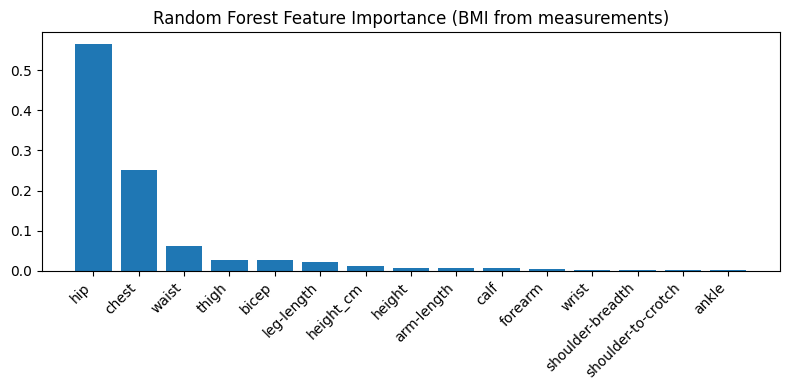

In [6]:
# Feature columns: anthropometric measurements + height_cm
feature_cols = [
    'ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm',
    'height', 'hip', 'leg-length', 'shoulder-breadth',
    'shoulder-to-crotch', 'thigh', 'waist', 'wrist',
    'height_cm'
]

train_df = df_full[df_full["split"] == "train"]
val_df   = df_full[df_full["split"] == "val"]
test_df  = df_full[df_full["split"] == "test"]

X_train = train_df[feature_cols]
y_train = train_df["bmi"]

X_val   = val_df[feature_cols]
y_val   = val_df["bmi"]

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Validation performance
preds = rf.predict(X_val)
mae = mean_absolute_error(y_val, preds)
mse = mean_squared_error(y_val, preds)
rmse = np.sqrt(mse)

print("Validation MAE:", mae)
print("Validation RMSE:", rmse)

# Feature importance
importances = rf.feature_importances_
fi = pd.DataFrame({"feature": feature_cols, "importance": importances}) \
        .sort_values("importance", ascending=False)

print(fi)

plt.figure(figsize=(8,4))
plt.bar(fi["feature"], fi["importance"])
plt.xticks(rotation=45, ha="right")
plt.title("Random Forest Feature Importance (BMI from measurements)")
plt.tight_layout()
plt.show()


In [7]:
class SilhouetteDataset(Dataset):
    def __init__(self, df, target_cols=["bmi", "height_cm", "weight_kg"]):
        self.df = df.reset_index(drop=True)
        self.target_cols = target_cols

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["img_path"]

        # Read as grayscale, resize, normalize
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (256, 256))
        img = img.astype("float32") / 255.0  # [0,1]

        # (1, H, W)
        img = np.expand_dims(img, axis=0)
        img = torch.tensor(img, dtype=torch.float32)

        # Targets: BMI, height_cm, weight_kg
        y = torch.tensor(row[self.target_cols].values.astype("float32"))

        return img, y


In [8]:
train_df = df_full[df_full["split"] == "train"]
val_df   = df_full[df_full["split"] == "val"]
test_df  = df_full[df_full["split"] == "test"]

train_dataset = SilhouetteDataset(train_df)
val_dataset   = SilhouetteDataset(val_df)
test_dataset  = SilhouetteDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Quick sanity check: one batch
imgs, targets = next(iter(train_loader))
print("Batch image shape:", imgs.shape)      # [B, 1, 256, 256]
print("Batch targets shape:", targets.shape) # [B, 3]


Batch image shape: torch.Size([32, 1, 256, 256])
Batch targets shape: torch.Size([32, 3])


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SilhouetteCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # -------------------------
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 256 -> 128

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 128 -> 64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -> 32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 -> 16

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # Output: [B, 256, 1, 1]
        )

        # Regression head (3 outputs: BMI, height_cm, weight_kg)
        self.regressor = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten: [B, 256]
        out = self.regressor(x)
        return out

# Instantiate model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SilhouetteCNN().to(device)

model


SilhouetteCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [11]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    epoch_loss = 0

    for imgs, targets in loader:
        imgs = imgs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * imgs.size(0)

    return epoch_loss / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(device)
            targets = targets.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, targets)

            epoch_loss += loss.item() * imgs.size(0)

    return epoch_loss / len(loader.dataset)


In [12]:
num_epochs = 15

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss = evaluate(model, val_loader, criterion)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch 01 | Train Loss: 3480.1343 | Val Loss: 117.9072
Epoch 02 | Train Loss: 187.8903 | Val Loss: 640.0003
Epoch 03 | Train Loss: 184.7582 | Val Loss: 357.7020
Epoch 04 | Train Loss: 177.9740 | Val Loss: 310.4958
Epoch 05 | Train Loss: 173.4456 | Val Loss: 524.3607
Epoch 06 | Train Loss: 171.4296 | Val Loss: 93.0868
Epoch 07 | Train Loss: 172.6279 | Val Loss: 224.6512
Epoch 08 | Train Loss: 169.7862 | Val Loss: 107.3341
Epoch 09 | Train Loss: 166.4147 | Val Loss: 184.4933
Epoch 10 | Train Loss: 168.9093 | Val Loss: 94.1720
Epoch 11 | Train Loss: 163.5377 | Val Loss: 254.4090
Epoch 12 | Train Loss: 165.7294 | Val Loss: 380.8962
Epoch 13 | Train Loss: 163.5814 | Val Loss: 196.1167
Epoch 14 | Train Loss: 151.8844 | Val Loss: 162.4430
Epoch 15 | Train Loss: 143.8821 | Val Loss: 92.2116


In [13]:
def evaluate_metrics(model, loader):
    model.eval()

    preds_list = []
    targets_list = []

    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(device)
            outputs = model(imgs).cpu().numpy()
            preds_list.append(outputs)
            targets_list.append(targets.numpy())

    preds = np.vstack(preds_list)
    targets = np.vstack(targets_list)

    mae = np.mean(np.abs(preds - targets), axis=0)
    rmse = np.sqrt(np.mean((preds - targets) ** 2, axis=0))

    return mae, rmse

mae, rmse = evaluate_metrics(model, test_loader)

print("Test MAE (BMI, height_cm, weight_kg):", mae)
print("Test RMSE:", rmse)


Test MAE (BMI, height_cm, weight_kg): [ 3.526224  8.438367 13.272531]
Test RMSE: [ 5.62415  10.302054 19.20632 ]
